Learning EDA and Feature Engineering

Below are some of the most helpful resources to learn different aspects of EDA and FE.
- Data Manipulation: [.](https://www.mit.edu/~amidi/teaching/data-science-tools/study-guide/data-manipulation-with-python/#)
- Data Preprocessing: [..](https://www.mit.edu/~amidi/teaching/data-science-tools/study-guide/data-preprocessing-with-python/#)

![image-3.png](../assets/ds_overview.webp)

## EDA - Exploratory Data Analysis

![image.png](../assets/EDA_thingy.png)

## Broad Overview
![image-2.png](../assets/img_.png)

sources: 
1. [blog post](https://blog.csdn.net/AlisonYao/article/details/107879142)
2. [eda_yt](https://www.youtube.com/watch?v=fHFOANOHwh8&t=2356s)


### EDA Types:

| EDA Type                            |                                                                                                                                                    Numerical vs Numerical | Numerical vs Categorical                                                                                                                     | Categorical vs Categorical                                                            |
| ----------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------: | -------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------- |
| **Univariate** : Analysis of a single variable |                              Histogram, KDE (density), Boxplot, Stem-and-leaf, Summary stats (mean, median, std, IQR), skew/kurtosis, normality test (Shapiro/Kolmogorov) | Bar plot of group means/counts, value_counts, frequency table, mode                                                                          | Frequency table, bar plot, pie chart (sparingly)                                      |
| **Bivariate** : Analysis of two variables | Scatter plot (optionally with regression/loess), hexbin (for dense data), jointplot, correlation (Pearson/Spearman/Kendall), covariance, scatter with color/size encoding | Boxplot / Violin / Swarm / Strip / Point plots showing distribution of numeric by category; group means ± CI; ANOVA / t-test for differences | Contingency table, stacked/grouped bar plot, mosaic plot, chi-square test, Cramer’s V |
| **Multivariate** : Analysis of multiple variables |                                         Pairplot (scatter + hist), Correlation heatmap, PCA / biplot, clustering visual (kmeans labels), dimension reduction (t-SNE/UMAP) | Pairplot with hue, facet grid by category, parallel coordinates, conditional distributions                                                   | Pivot tables, heatmaps of aggregated metrics, mosaic with additional variables        |
| **Time / Order aware** : Analysis that considers the temporal or ordered nature of data |                                                                                                       Rolling mean, autocorrelation (ACF/PACF), time series decomposition | Grouped time series plots, grouped rolling stats                                                                                             | —                                                                                     |
| **Missing / Outliers / Transforms** : Handling missing values, outliers, and data transformations |                                                              Missing-value matrix, boxplot/Q-Q for outliers, log/boxcox transforms, winsorize, robust stats (median, MAD) | Compare missingness or outlier rates by group                                                                                                | Missingness contingency, treat rare categories                                        |

In [1]:
#@title EDA and Feature Engineering 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

*Always know that EDA and FE are iterative and intertwined processes. You may need to go back and forth between them as you discover insights and refine your features.*

**Always think about the data from the perspective of the problem you are trying to solve - And thus frame questions which will guide your analysis**

In [2]:
df = pd.read_csv("datasets/Zomatodataset/zomato.csv", encoding='latin1')

# whene ever you get this kinda error: ""utf-8' codec can't decode byte 0xed in position 7044.."" 
# Remember to use somekindof encoding format.. 

In [3]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [5]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [6]:
df.isna().sum() #thus as we can see we don't have any null vals, except in cuisines col
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


Diff Data Types: 

- When choosing between these data types, consider the range of values you need to represent and the precision required for your calculations. For example, if you only need to store small integers, using int8 can save memory compared to int64. However, if you need to store large integers or require high precision for floating-point numbers, using int64 or float64 would be more appropriate.

| Data Type | Description | Range (for integers) | Precision (for floats) | Memory Usage |
|-----------|-------------|----------------------|-----------------------|--------------|
| int8      | 8-bit signed integer | -128 to 127          | N/A                   | 1 byte       |
| int16     | 16-bit signed integer | -32,768 to 32,767     | N/A                   | 2 bytes      |
| int32     | 32-bit signed integer | -2,147,483,648 to 2,147,483,647 | N/A                   | 4 bytes      |
| int64     | 64-bit signed integer | -9,223,372,036,854,775,808 to 9,223,372,036,854,775,807 | N/A                   | 8 bytes      |
| float16   | 16-bit floating-point | N/A                  | ~3.3 decimal digits   | 2 bytes      |
| float32   | 32-bit floating-point | N/A                  | ~7 decimal digits     | 4 bytes      |
| float64   | 64-bit floating-point | N/A                  | ~15-17 decimal digits   | 8 bytes      |


Step by step for data analysis:
- Search for missing values 
- Explaore about the numerical features and their distribution (skewness, outliers, normality)
- Explore about the categorical variables/features and their distribution (unique values, frequency)
- Finding relationship between features..


In [7]:
df.isnull().sum()
# now that we know cuisines have 9 missing values let's exlaore if there's any relationship of it with any other variables

# Another way
[features for features in df.columns if df[features].isnull().sum()>0] # a really basic way to find which all features have null vals

['Cuisines']

In [8]:
# sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis') if you want to visvalise the null values 


In [9]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [10]:
# import another dataset we had in dir
df_country = pd.read_excel("Zomatodataset/Country-Code.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'Zomatodataset/Country-Code.xlsx'

In [ ]:
df_country

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


In [ ]:
df.columns #we guessed if this df_country dataset can somehow connet with of df dataset?? and yess we found a common colmn -> "Country Code" 
#let's try merging them both 
# finding relations between the datasets

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [ ]:
final_df = pd.merge(df, df_country, on="Country Code", how='left' ) #how give option as to how would you like to join: left join, right join or inner join 

Explain with examples the different types of joins: left, right, inner, outer joins with examples and visualization below in tabular format: 
| Join Type | Description | Example | Visualization |
|-----------|-------------|---------|---------------|
| Left Join  | Returns all records from the left table and the matched records from the right table. If there is no match, the result is NULL on the right side. | If we have two tables, Customers and Orders, a left join on CustomerID would return all customers and their orders, but if a customer has no orders, the order details would be NULL. | 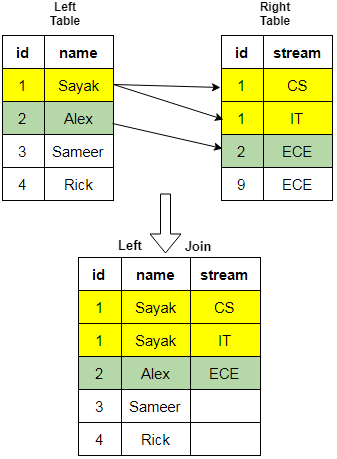 |
| Right Join | Returns all records from the right table and the matched records from the left table. If there is no match, the result is NULL on the left side. | Using the same Customers and Orders tables, a right join on CustomerID would return all orders and their corresponding customers, but if an order has no associated customer, the customer details would be NULL. | 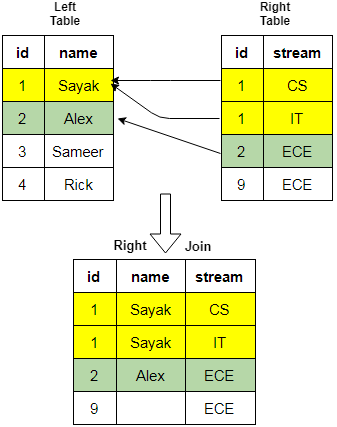 |
| Inner Join | Returns only the records that have matching values in both tables. | An inner join on CustomerID between Customers and Orders would return only those customers who have placed orders, excluding any customers without orders and any orders without customers. | 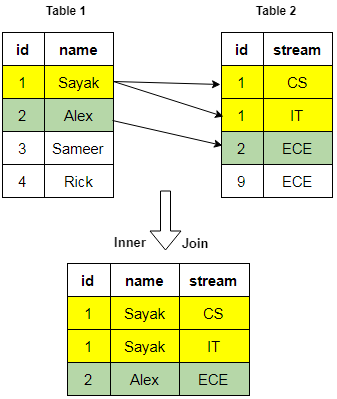 |
| Outer Join | Returns all records when there is a match in either left or right table. If there is no match, the result is NULL on the side that does not have a match. | A full outer join on CustomerID between Customers and Orders would return all customers and all orders, with NULLs in place where there is no match (i.e., customers without orders and orders without customers). | ![Outer Join Visualization](https://www.sqlshack.com/wp-content/uploads/2019/10/full-outer-join.png) |

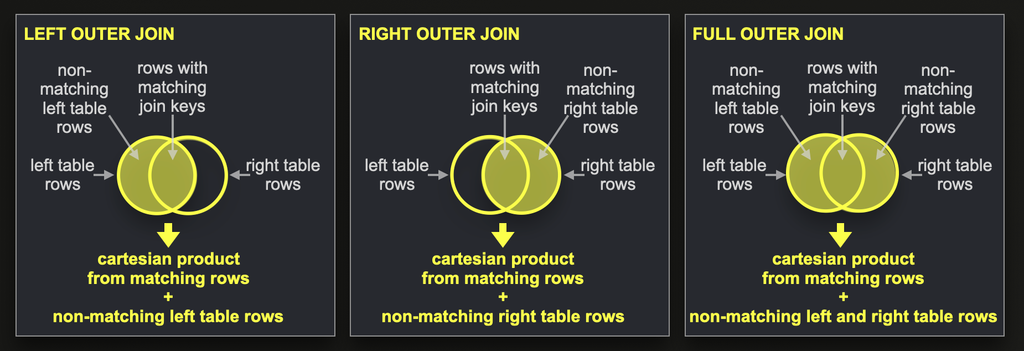

*For better understanding visit below link*
[Working with JOINs](https://clickhouse.com/docs/guides/working-with-joins)

```python
final_df = pd.merge(df, df_country, on="Country Code", how='left' )
"""
> __, __ : the datset1, datset2
> on: The common cols between the two datasets
> how: the type of join you want to perform -> Ref the above explanations and defs
"""
```


In [ ]:
final_df.dtypes #finding the datatypes of the cols

Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
Country                     str
dtype: object

In [ ]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='str')

<Axes: >

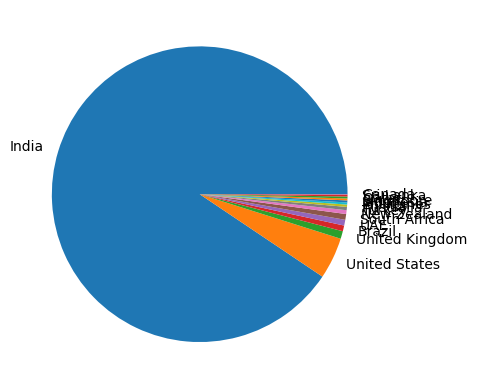

In [ ]:
# let's seen or look for meaningful things and write observation for those: 
# final_df["Country"].value_counts()
final_df["Country"].value_counts().plot(kind= "pie")

In [ ]:
country_names = final_df["Country"].value_counts().index
country_vals = final_df["Country"].value_counts().values


([<matplotlib.patches.Wedge at 0x7f3e3072f710>,
 [Text(-1.082974277862112, 0.1927867046480056, 'India'),
  Text(1.0772816964394372, -0.22240536530526556, 'United States'),
  Text(1.0995865232164619, -0.030157552300104404, 'United Kingdom')],
 [Text(-0.5907132424702428, 0.10515638435345759, '94.39%'),
  Text(0.5876081980578747, -0.12131201743923574, '4.73%'),
  Text(0.5997744672089791, -0.01644957398187513, '0.87%')])

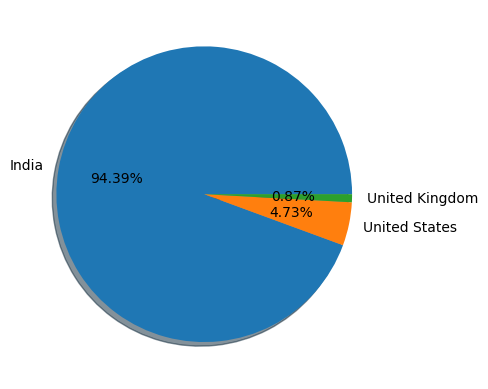

In [ ]:
# plt.pie(labels = country_names, x = country_vals) #the plot's a little messy so let's clear it out
# say we want to have the top  or 5 country which use zomato

plt.pie(x = country_vals[:3], labels = country_names[:3], autopct = '%1.2f%%', shadow= True)

# how to get better and clear pie cahrt? without any overlaps? Explore!

Write your observations:
1. Zomato's maximum transctions are Indian
2. The 2nd and 3rd are USA and UK by 4.73%, 0.87% repectively

In [ ]:
# A few more observatiosn letr's find some more realtiosn
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='str')

In [ ]:
rating_df = final_df.groupby(["Aggregate rating", 'Rating color', 'Rating text']).size().reset_index().rename(columns={0 : 'Rating Count'})
#size : Number of rows in each group
rating_df

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


### Conclusions or Observations : 
1. rating from 4.5- 4.9 : Excellent
2. When rating between 3.5-3.9: Very Good
3. When the rating is bwt 3.5 - 3.9: Good
4. when the rating is bwt 2.5-3.0 : Average
5. whene the rating is bwt 2.0-2.4 : Poor

let's plot it


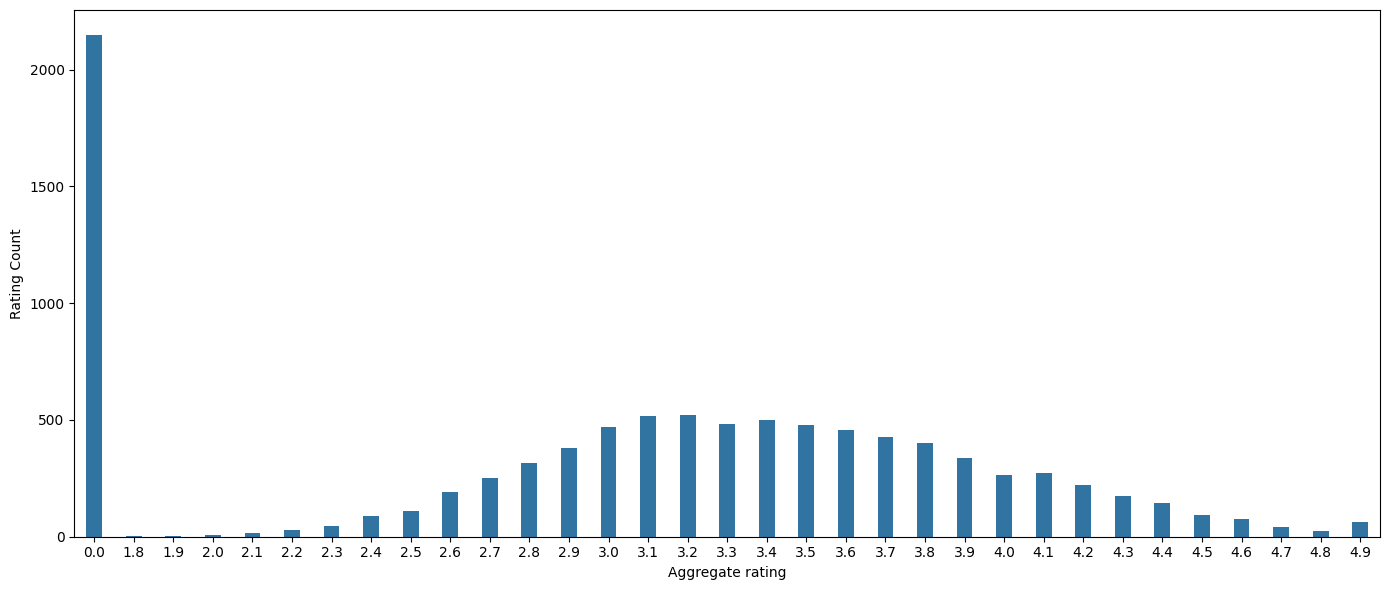

In [ ]:
import matplotlib
plt.figure(figsize=(14,6))
sns.barplot(x = "Aggregate rating", y= "Rating Count", data= rating_df, width=0.5, gap=0.2) #for colorful graphs: palette=rating_df["Rating color"].tolist() or better use hue = "Rating color"

# rating_df.plot(kind='bar', x= "Aggregate rating", y= "Rating Count")

# plt.xticks(rotation=45) #to twist the x labels
plt.tight_layout()

plt.show()

It's always a good practice to color and format your plots to make them more visually appealing and easier to interpret. 

In [ ]:
# the colors
palette=[i for i in df['Rating color'].unique().tolist()]
palette

['Dark Green', 'Green', 'Yellow', 'Orange', 'White', 'Red']

In [ ]:
# since Dark Green is not reconsied let's chage it's color to something diffrent
df['Rating color'] = df['Rating color'].replace('Dark Green', 'Blue')
df['Rating color'].unique().tolist()

# this is how you replace a group data from a column across the dataset with hindering anyhitng else/

['Blue', 'Green', 'Yellow', 'Orange', 'White', 'Red']

In [ ]:
rating_df['Rating color'] = rating_df['Rating color'].replace('Dark Green', 'Blue')
rating_df['Rating color'].unique().tolist()

['White', 'Red', 'Orange', 'Yellow', 'Green', 'Blue']

In [ ]:
rating_df[rating_df['Rating color']=='White']

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148


<Axes: xlabel='Aggregate rating', ylabel='Rating Count'>

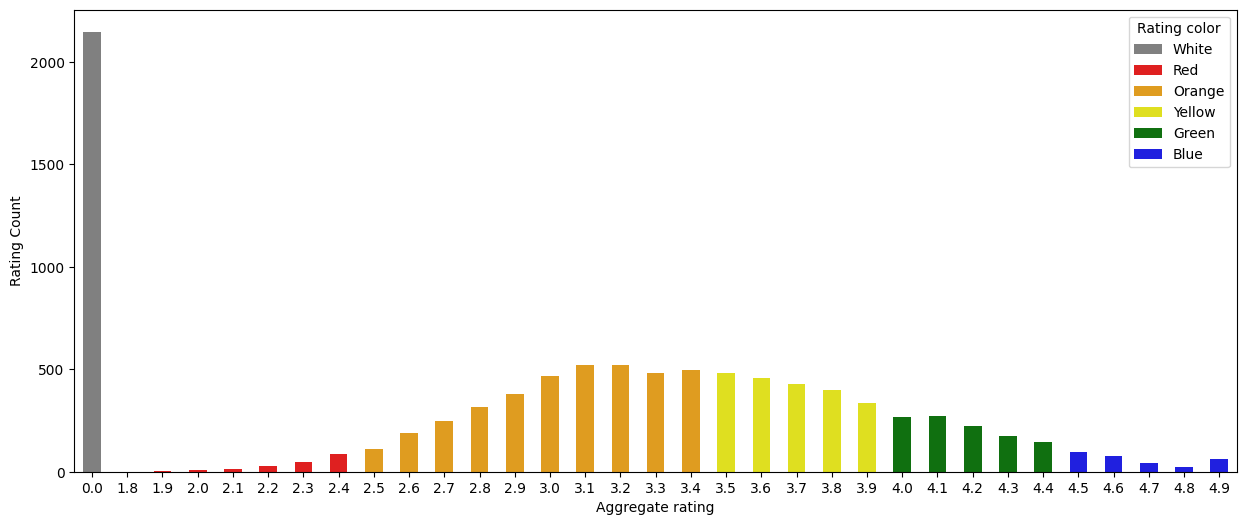

In [ ]:
plt.figure(figsize=(15,6))
# sns.barplot(x = "Aggregate rating", y= "Rating Count", data= rating_df, width=0.5, hue= "Rating color")
sns.barplot(x = "Aggregate rating", y= "Rating Count", data= rating_df, width=0.5,hue= "Rating color", palette=['Grey', 'Red', 'Orange', 'Yellow', 'Green', 'Blue'], dodge= False) #using of hue is essential else you can't map the color with the plot for each group of data - like only for 0.0 -> should the bar have color White or grey
# The hue affirms the above comment and the palette help in custom coloring.

In [ ]:
rating_df.head()

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15


In [ ]:
# df[['Rating count', 'Rating color']].groupby('Rating color').count()
total = rating_df['Rating Count'].sum()
color_weitage = rating_df.groupby('Rating color')['Rating Count'].sum().reset_index() #.rest_index is essential as to reset the dataset view for any set-dataset you create, else you can understad by remove it the clear diffrence.

color_weitage['Weitage'] = (color_weitage['Rating Count']/total)*100
color_weitage = color_weitage.sort_values(by = 'Weitage', ascending=False)
orderd_color = color_weitage['Rating color'].tolist()

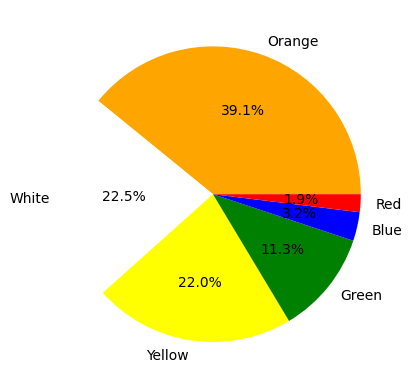

,Rating color,Rating Count,Weitage
2,Orange,3737,39.126793
4,White,2148,22.489792
5,Yellow,2100,21.987226
1,Green,1079,11.297246
0,Blue,301,3.151502
3,Red,186,1.947440


In [ ]:
plt.pie( x=color_weitage['Weitage'], labels = color_weitage['Rating color'], autopct='%1.1f%%', colors=orderd_color) #make sure that the order matchs that of the indexs
plt.show()
display(color_weitage)

### Now conclude the observations from the plot:
1. The Grey color, which is 'not rated' is the higest amoung all rating
2. Maximum rating is in Orange color which is between 2.5-3.4

### But what if we encounter empty or misssing values in the dataset?
- so by the above observations we can find the average rating of the max rating which is in orange color and then we can replace the missing values with that average rating.

The observation from the rating we found above: 


In [ ]:
final_df.groupby(["Rating text"])['Restaurant Name'].count()

Rating text
Average      3737
Excellent     301
Good         2100
Not rated    2148
Poor          186
Very Good    1079
Name: Restaurant Name, dtype: int64

In [ ]:
# Numerical Variables
df.groupby(['Rating text']).size()

Rating text
Average      3737
Excellent     301
Good         2100
Not rated    2148
Poor          186
Very Good    1079
dtype: int64

/tmp/ipykernel_28499/754475498.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating text', y='Rating Count', data=rating_df, palette='viridis')


<Axes: xlabel='Rating text', ylabel='Rating Count'>

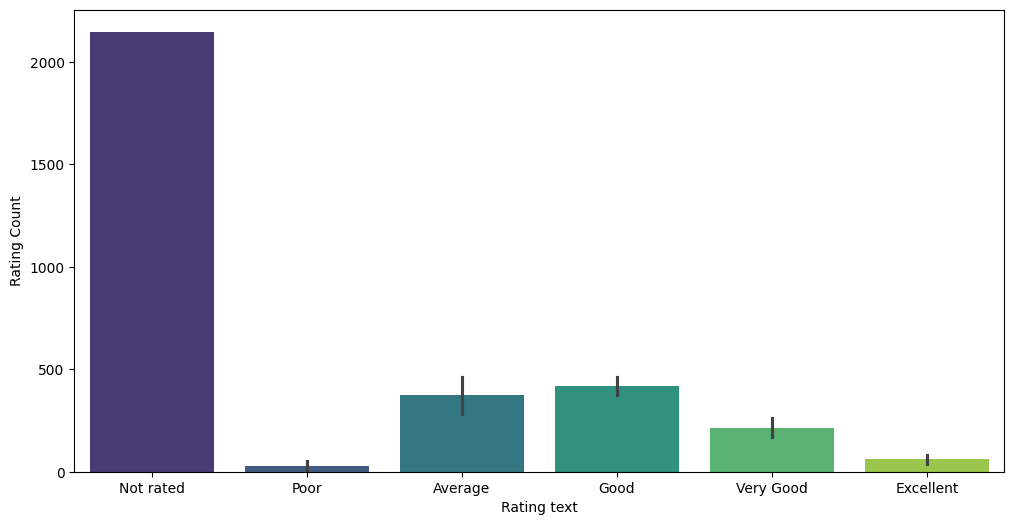

In [ ]:
# also can plot like this to find realtions
plt.figure(figsize=(12,6))
# sns.countplot(x = 'Rating Count', data = rating_df, palette=orderd_color)
sns.barplot(x='Rating text', y='Rating Count', data=rating_df, palette='viridis')

/tmp/ipykernel_28499/2127619807.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rating_df, x='Rating color', palette='viridis') #does the calculations itself and creates the plot


<Axes: xlabel='Rating color', ylabel='count'>

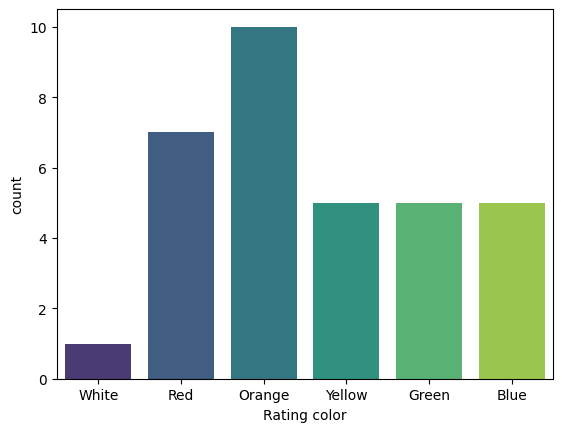

In [ ]:
sns.countplot(data=rating_df, x='Rating color', palette='viridis') #does the calculations itself and creates the plot

## Doing some indepth analysis now, to find the relation between the rating count and the rating text.

In [ ]:
# we didn't had the country name in the df, it had another dataset for it so we just merged the df 
df = pd.merge(left=df, right=df_country, how = 'inner', on='Country Code')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Blue,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Blue,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Blue,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Blue,Excellent,229,Phillipines


In [ ]:
# df = df.drop(['Country_x','Country_y'], axis=1)

In [ ]:
#Q1. find the countries name that had given 0 rating
# M-1
display(df[df['Aggregate rating']==0.0]['Country'].reset_index().groupby('Country').count())
#m-2
display(df[df['Rating color']=='White']['Country'].reset_index().groupby('Country').count())

,index
Country,
Brazil,5
India,2139
United Kingdom,1
United States,3


,index
Country,
Brazil,5
India,2139
United Kingdom,1
United States,3


### We found from above question
1. India has the highest no of 0 rating 

In [ ]:
#Q.2 find which currency is used by which country
df.head() # we couldn't see the currency colm and it gets truncated in .head() thus always use df.columns
# df.columns
# df.groupby(['Country', 'Currency']).size().reset_index() # this is right
df[['Country', 'Currency']].groupby(['Country', 'Currency']).size().reset_index() # this is also right


,Country,Currency,0
0,Australia,Dollar($),24
1,Brazil,Brazilian Real(R$),60
2,Canada,Dollar($),4
3,India,Indian Rupees(Rs.),8652
4,Indonesia,Indonesian Rupiah(IDR),21
5,New Zealand,NewZealand($),40
6,Phillipines,Botswana Pula(P),22
7,Qatar,Qatari Rial(QR),20
8,Singapore,Dollar($),20
9,South Africa,Rand(R),60


In [ ]:
#Q.3 which country has online delivery? 
df[df['Has Online delivery']== 'Yes'].groupby('Country').size().reset_index()

,Country,0
0,India,2423
1,UAE,28


In [ ]:
# incase you want to see which country has or not has online deliv
df.groupby(['Country', 'Has Online delivery']).size().reset_index()


,Country,Has Online delivery,0
0,Australia,No,24
1,Brazil,No,60
2,Canada,No,4
3,India,No,6229
4,India,Yes,2423
5,Indonesia,No,21
6,New Zealand,No,40
7,Phillipines,No,22
8,Qatar,No,20
9,Singapore,No,20


Observatiosn :
1. The online dlvry is avalibale in Indian and UK 

In [ ]:
# Q.4 create a pie chart distribution based on cities
city_stats = df.groupby(['Country', 'City']).value_counts().reset_index()
city_ditribution = city_stats.stack()
display(city_ditribution)

0     Country                   Australia
      City                       Armidale
      Restaurant ID              16611114
      Restaurant Name     Whitebull Hotel
      Country Code                     14
                               ...       
9541  Aggregate rating                3.2
      Rating color                 Orange
      Rating text                 Average
      Votes                            16
      count                             1
Length: 219466, dtype: object

In [ ]:
city_labels = df.City.value_counts().index
city_values = df.City.value_counts().values

city_counts = df['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Count']

([<matplotlib.patches.Wedge at 0x7f3e2470ff20>,
 [Text(-0.6145353730323401, 0.9123301350344637, 'New Delhi'),
  Text(0.06236774886414425, -1.0982305149200777, 'Gurgaon'),
  Text(0.878904221413572, -0.6614585169014024, 'Noida'),
  Text(1.0922218482114119, -0.1305811406354216, 'Faridabad'),
  Text(1.099946277419523, -0.010871374841004297, 'Ghaziabad')],
 [Text(-0.33520111256309454, 0.4976346191097074, '68.87%'),
  Text(0.03401877210771504, -0.5990348263200423, '14.07%'),
  Text(0.479402302589221, -0.36079555467349217, '13.59%'),
  Text(0.5957573717516791, -0.07122607671022996, '3.16%'),
  Text(0.5999706967742853, -0.00592984082236598, '0.31%')])

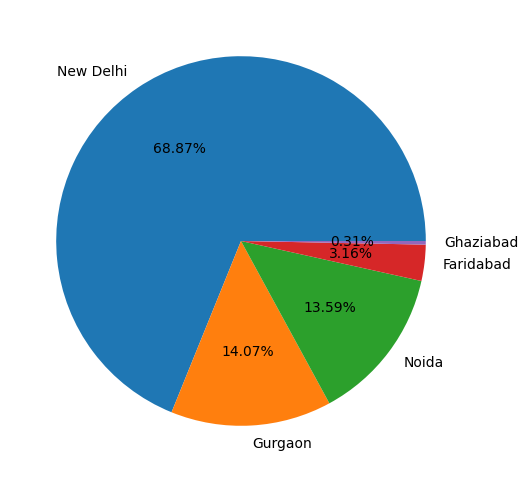

In [ ]:
plt.figure(figsize=(12, 6))
plt.pie(x= city_values[:5], labels= city_labels[:5], autopct='%1.2f%%')